In [1]:
import json

In [2]:
with open('1-raw/ustad_360_stem.json', 'r') as f:
    others = json.load(f)

In [3]:
len(others)

13903

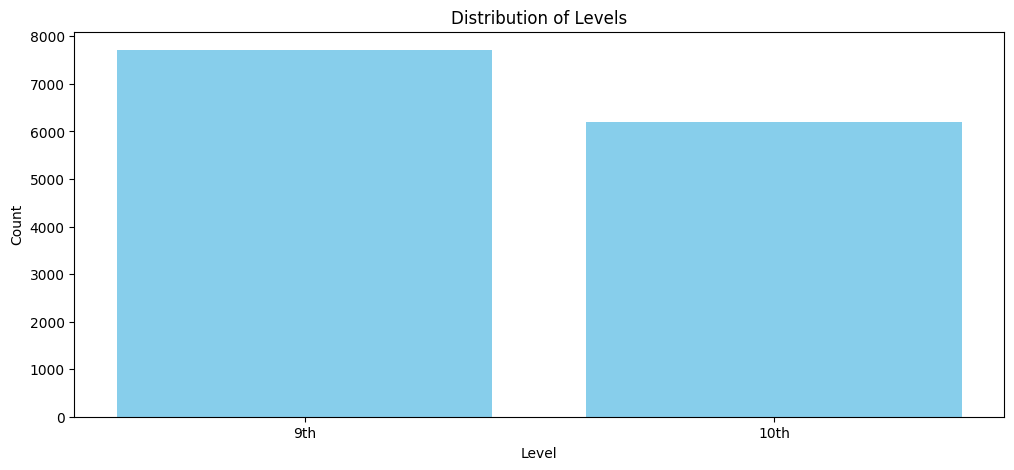

In [4]:
# check distribution of levels and subdomains through bar plots.
import matplotlib.pyplot as plt
from collections import Counter

levels = [item['level'] for item in others]
level_counts = Counter(levels)

plt.figure(figsize=(12, 5))
plt.bar(level_counts.keys(), level_counts.values(), color='skyblue')
plt.title('Distribution of Levels')
plt.xlabel('Level')
plt.ylabel('Count')
plt.show()

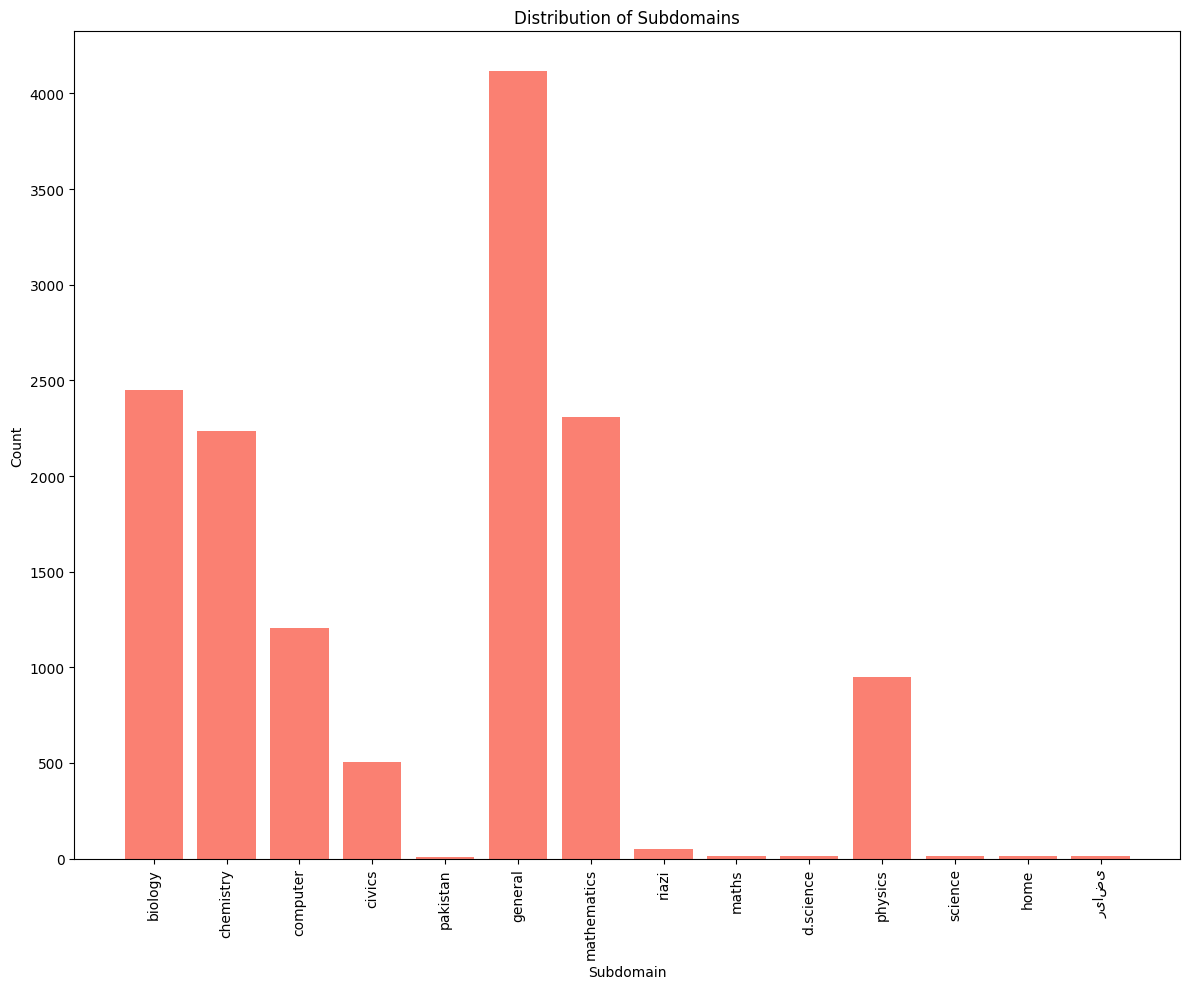

In [5]:
subdomains = [item['subdomain'] for item in others]
subdomain_counts = Counter(subdomains)

# rotate x-axis labels for better readability to 90 degrees
plt.figure(figsize=(12, 10))
plt.bar(subdomain_counts.keys(), subdomain_counts.values(), color='salmon')
plt.title('Distribution of Subdomains')
plt.xlabel('Subdomain')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [6]:
# find unique subdomains 
unique_subdomains = set(subdomains)
len(unique_subdomains)

14

In [7]:
# find the unique domains in the dataset when subdomain is general
general_domains = set(item['domain'] for item in others if item['subdomain'] == 'general')
general_domains

{'General Knowledge / Science (DGK Grade 9)',
 'General Mathematics',
 'General Mathematics (Arts Group)',
 'General Mathematics (Arts Group) SSC Part-I',
 'General Mathematics (Arts Group) SSC Part-II',
 'General Mathematics (Arts Group) SSC-I',
 'General Mathematics (Arts)',
 'General Mathematics (Arts) SSC',
 'General Mathematics (Arts) SSC Part-I',
 'General Mathematics (Arts) SSC Part-II',
 'General Mathematics (Arts) SSC-I',
 'General Mathematics (Arts) SSC-II',
 'General Mathematics (Compulsory) Secondary Part I',
 'General Mathematics (General Section) SSC-I',
 'General Mathematics (جزل ریاضی) SSC-I Group 2',
 'General Mathematics (جزل ریاضی) SSC-II Group 2',
 'General Mathematics (جنرل ریاضی) SSC-II',
 'General Mathematics (جنرل ریاضی) SSC-II Group 1',
 'General Mathematics 10th Class',
 'General Mathematics 8th Class',
 'General Mathematics 9th Class',
 'General Mathematics Arts Group',
 'General Mathematics Group-I',
 'General Mathematics Group-II',
 'General Mathematics SSC

In [8]:
# when subdomain is general update the subdomain to the first 2 words of the domain
for item in others:
    if item['subdomain'] == 'general':
        item['subdomain'] = ' '.join(item['domain'].split()[:2])

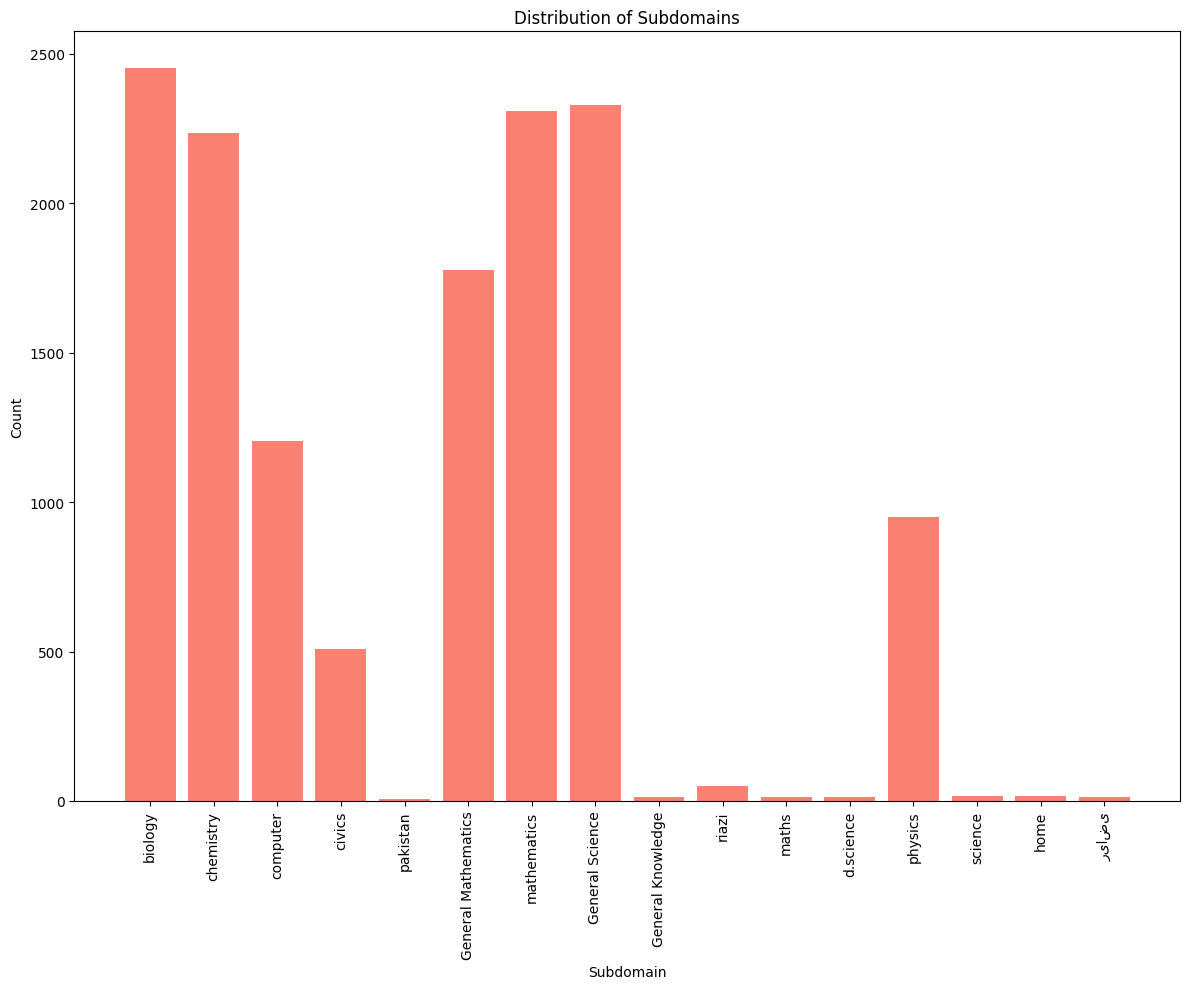

In [9]:
subdomains = [item['subdomain'] for item in others]
subdomain_counts = Counter(subdomains)

# rotate x-axis labels for better readability to 90 degrees
plt.figure(figsize=(12, 10))
plt.bar(subdomain_counts.keys(), subdomain_counts.values(), color='salmon')
plt.title('Distribution of Subdomains')
plt.xlabel('Subdomain')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [10]:
# find unique subdomains
unique_subdomains = set(subdomains)
unique_subdomains

{'General Knowledge',
 'General Mathematics',
 'General Science',
 'biology',
 'chemistry',
 'civics',
 'computer',
 'd.science',
 'home',
 'mathematics',
 'maths',
 'pakistan',
 'physics',
 'riazi',
 'science',
 'ریاضی'}

In [11]:
subdomain_mapping = {
    'civics': 'civics',
    'civics/pakistan': 'civics',
    'civics/political': 'civics',
    'حصہ': 'civics',
    'commerce': 'commerce',
    'commerce/accounting': 'commerce',
    'commerce/banking': 'commerce',
    'commerce/business': 'commerce',
    'commercial': 'commerce',
    'usool': 'commerce',
    'usool-e-tijarat': 'commerce',
    'accounting/book-keeping': 'commerce',
    'accounting/commerce': 'commerce',
    'asool': 'commerce',
    'banking': 'commerce',
    'economics': 'economics',
    'economics/pakistan': 'economics',
    'اصول': 'economics',
    'معاشیات': 'economics',
    'principals': 'economics',
    'principles': 'economics',
    'education': 'education',
    'education/pedagogy': 'education',
    'علم': 'education',
    'ethics': 'ethics',
    'akhlaqiat': 'ethics',
    'ikhlakiyat': 'ethics',
    'ikhlaqiat': 'ethics',
    'general': 'geography',
    'geography': 'geography',
    'General Geography': 'geography',
    'geography/pakistan': 'geography',
    'geography/physical': 'geography',
    'health': 'health and physical education',
    'physical': 'health and physical education',
    'صحت': 'health and physical education',
    'home': 'home economics',
    'elements': 'home economics',
    'mabadiat': 'home economics',
    'مبادیات': 'home economics',
    'islamiat': 'islamic studies',
    'nafsiaat': 'psychology',
    'psychology': 'psychology',
    'نفسیات': 'psychology',
    'pakistan': 'pakistan studies',
    'pakistan studies': 'pakistan studies',
    'sociology': 'sociology',
    'عمرانیات': 'sociology',
    'biology': 'biology',
    'chemistry': 'chemistry',
    'civics': 'civics',
    'computer': 'computer science',
    'd.science': 'general science',
    'general': 'general science',
    'science': 'general science',
    'mathematics': 'mathematics',
    'maths': 'mathematics',
    'riazi': 'mathematics',
    'ریاضی': 'mathematics',
    'General Mathematics': 'mathematics',
    'General Science': 'general science',
    'physics': 'physics',
    'General Knowledge': 'general knowledge',
}

mapped_subdomains = [subdomain_mapping.get(subdomain, subdomain) for subdomain in subdomains]
mapped_subdomain_counts = Counter(mapped_subdomains)

# update the subdomain key in others with mapped subdomain
for item in others:
    item['subdomain'] = subdomain_mapping.get(item['subdomain'], item['subdomain'])

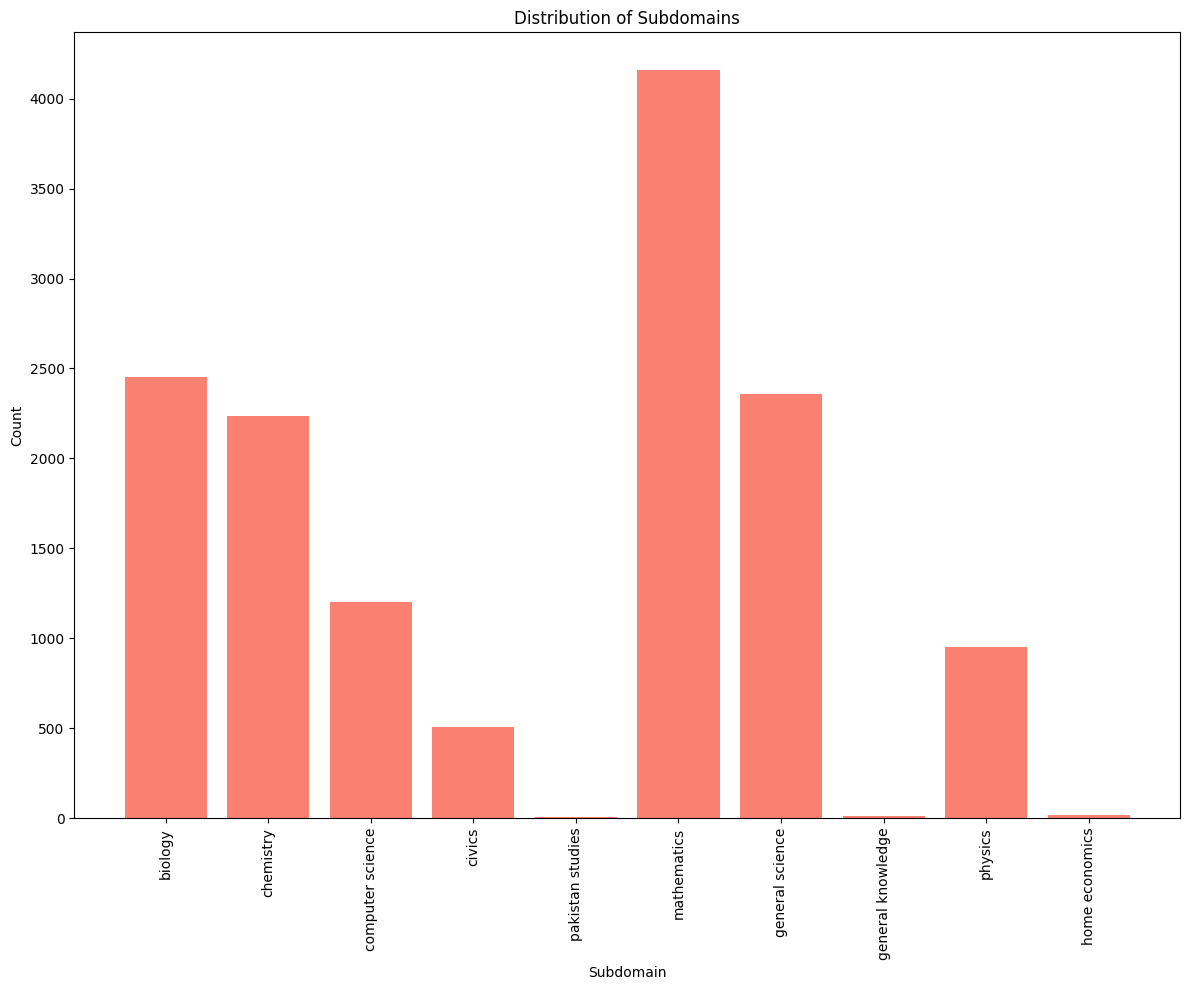

In [12]:
subdomains = [item['subdomain'] for item in others]
subdomain_counts = Counter(subdomains)

# rotate x-axis labels for better readability to 90 degrees
plt.figure(figsize=(12, 10))
plt.bar(subdomain_counts.keys(), subdomain_counts.values(), color='salmon')
plt.title('Distribution of Subdomains')
plt.xlabel('Subdomain')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [13]:
# update level key as follow:
# 9th-> SSC-I, 10th-> SSC-II, 11th-> HSSC-I, 12th-> HSSC-II
level_mapping = {
    '9th': 'SSC-I',
    '10th': 'SSC-II',
    '11th': 'HSSC-I',
    '12th': 'HSSC-II'
}

mapped_levels = [level_mapping.get(level, level) for level in levels]
mapped_level_counts = Counter(mapped_levels)
# update the level key in others with mapped level
for item in others:
    item['level'] = level_mapping.get(item['level'], item['level'])

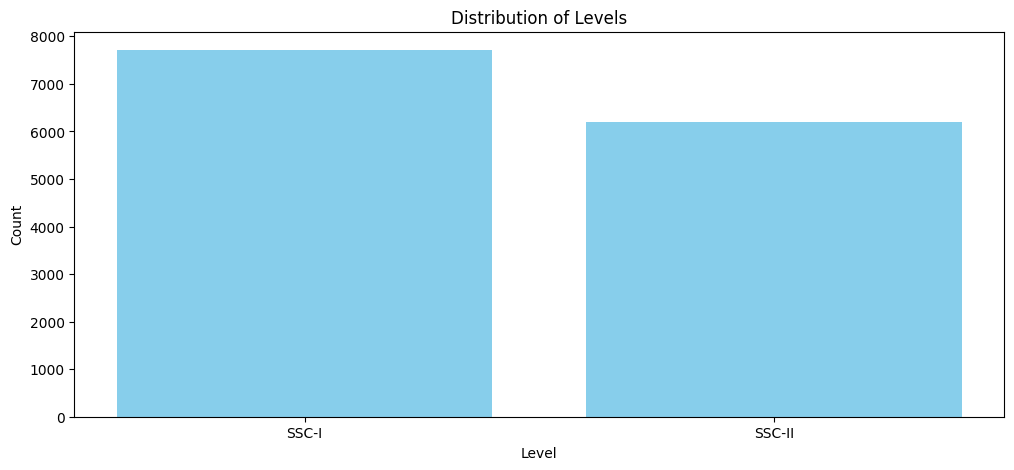

In [14]:
# check distribution of levels and subdomains through bar plots.
import matplotlib.pyplot as plt
from collections import Counter

levels = [item['level'] for item in others]
level_counts = Counter(levels)

plt.figure(figsize=(12, 5))
plt.bar(level_counts.keys(), level_counts.values(), color='skyblue')
plt.title('Distribution of Levels')
plt.xlabel('Level')
plt.ylabel('Count')
plt.show()

In [15]:
others[0]

{'question_number': 1,
 'question': 'لیکٹک ایسڈ کا فارمولا ہے۔',
 'options': {'A': 'NH3', 'B': 'C6H12O6', 'C': 'C3H6O3', 'D': 'C3H4O3'},
 'has_image': False,
 'image_bbox': None,
 'domain': 'Biology 9th Class',
 'subdomain': 'biology',
 'correct_option': None,
 'correct_index': None,
 'level': 'SSC-I',
 'page': 1,
 'source_url': '',
 'source_image': 'Biology%209-DGK-(G1+G2)-22_page_0001.jpg',
 'folder': 'Biology%209-DGK-(G1+G2)-22',
 'provider': 'gemini',
 'model': 'gemini-3-flash-preview'}

In [16]:
# add source_name key to each item in others with value 'ustad_360'
for item in others:
    item['source'] = 'Ustad 360'

In [17]:
with open('2-processed/ustad_360_stem.json', 'w', encoding='utf-8') as f:
    json.dump(others, f, ensure_ascii=False, indent=4)